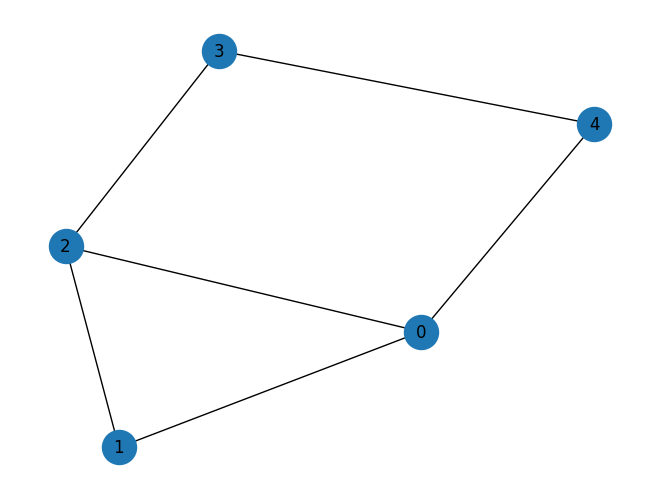

In [11]:
import numpy as np

import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from qiskit.circuit import Parameter

import sys
sys.path.append("../")
from clapton.clapton import claptonize
from clapton.ansatzes import circular_ansatz
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit

n = 5

graph = rx.PyGraph()

graph.add_nodes_from(np.arange(0, n, 1))
edge_list = [(0, 1, 1.0), (0, 2, 1.0), (0, 4, 1.0), (1, 2, 1.0), (2, 3, 1.0), (3, 4, 1.0)]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)
G=graph

In [12]:
from qiskit.quantum_info import SparsePauliOp
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list.

    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        paulis = ["I"] * len(graph)
        paulis[edge[0]], paulis[edge[1]] = "Z", "Z"

        weight = graph.get_edge_data(edge[0], edge[1])

        pauli_list.append(("".join(paulis)[::-1], weight))

    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
paulis,coeffs = cost_hamiltonian.paulis.to_labels(),cost_hamiltonian.coeffs.real

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'ZIIIZ', 'IIZZI', 'IZZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


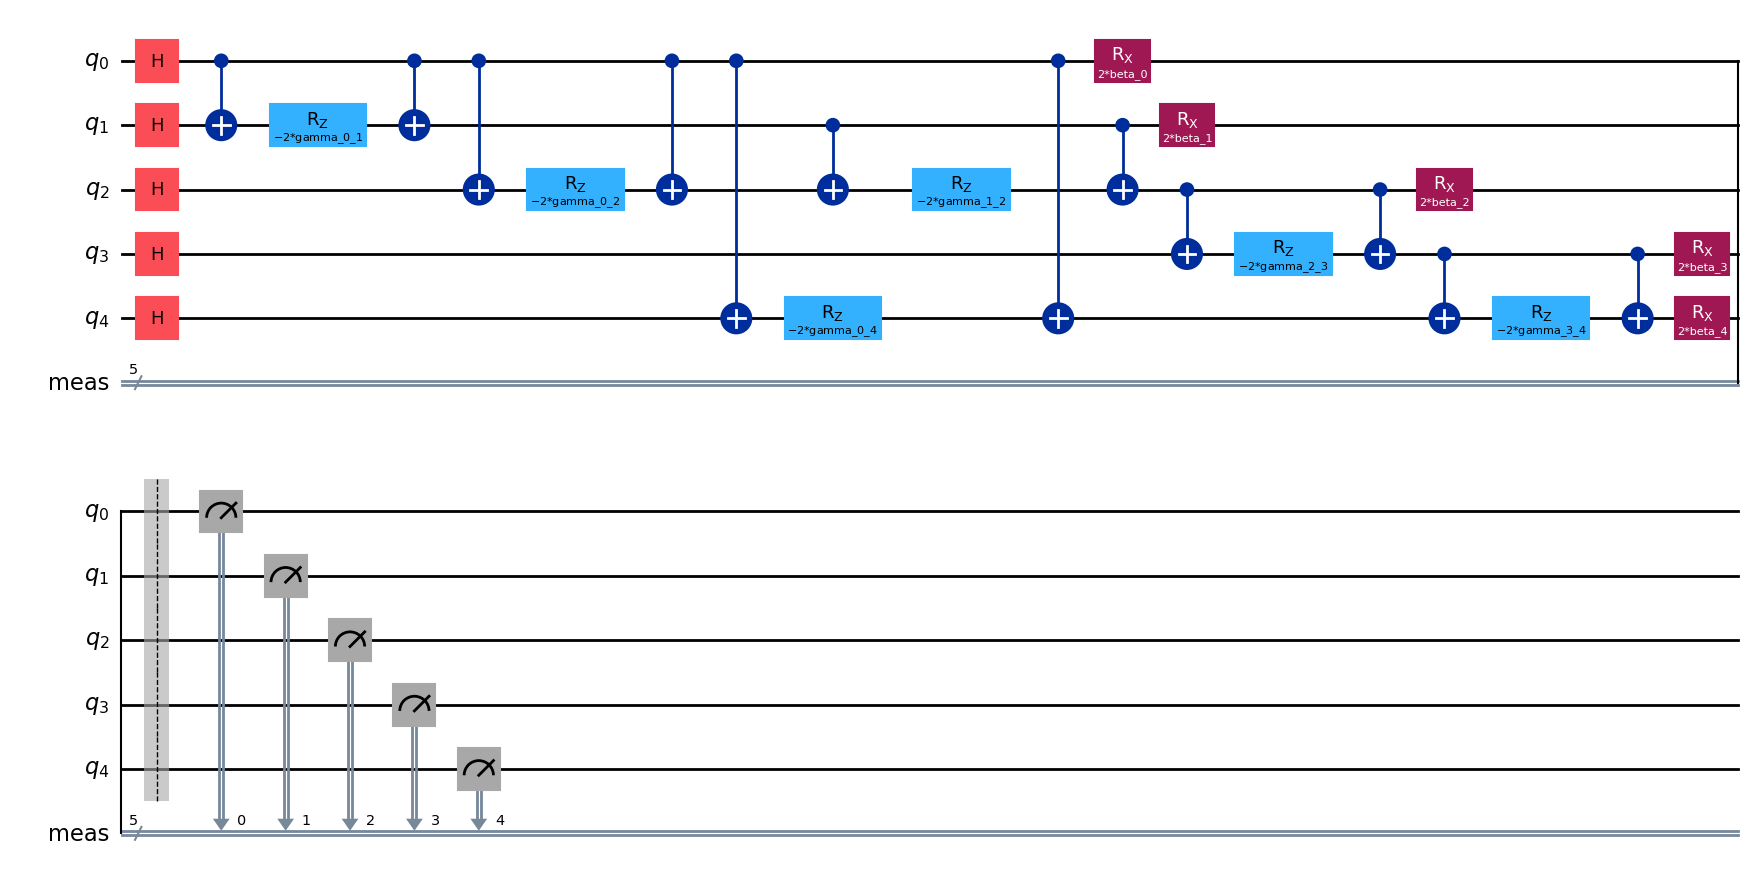

In [13]:
from qiskit.circuit.library import QAOAAnsatz



reps = 1
gamma_params = [Parameter(f'gamma_{i}_{j}') for i, j in G.edge_list()]
beta_params = [Parameter(f'beta_{i}') for i in G.node_indexes()]

# circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps,flatten=True)

circuit = multi_angle_qaoa_circuit(gamma_params,beta_params,n,G)


circuit.measure_all()

circuit.draw('mpl')

In [14]:
len(circuit.parameters),(circuit.parameters)

(11,
 ParameterView([Parameter(beta_0), Parameter(beta_1), Parameter(beta_2), Parameter(beta_3), Parameter(beta_4), Parameter(gamma_0_1), Parameter(gamma_0_2), Parameter(gamma_0_4), Parameter(gamma_1_2), Parameter(gamma_2_3), Parameter(gamma_3_4)]))

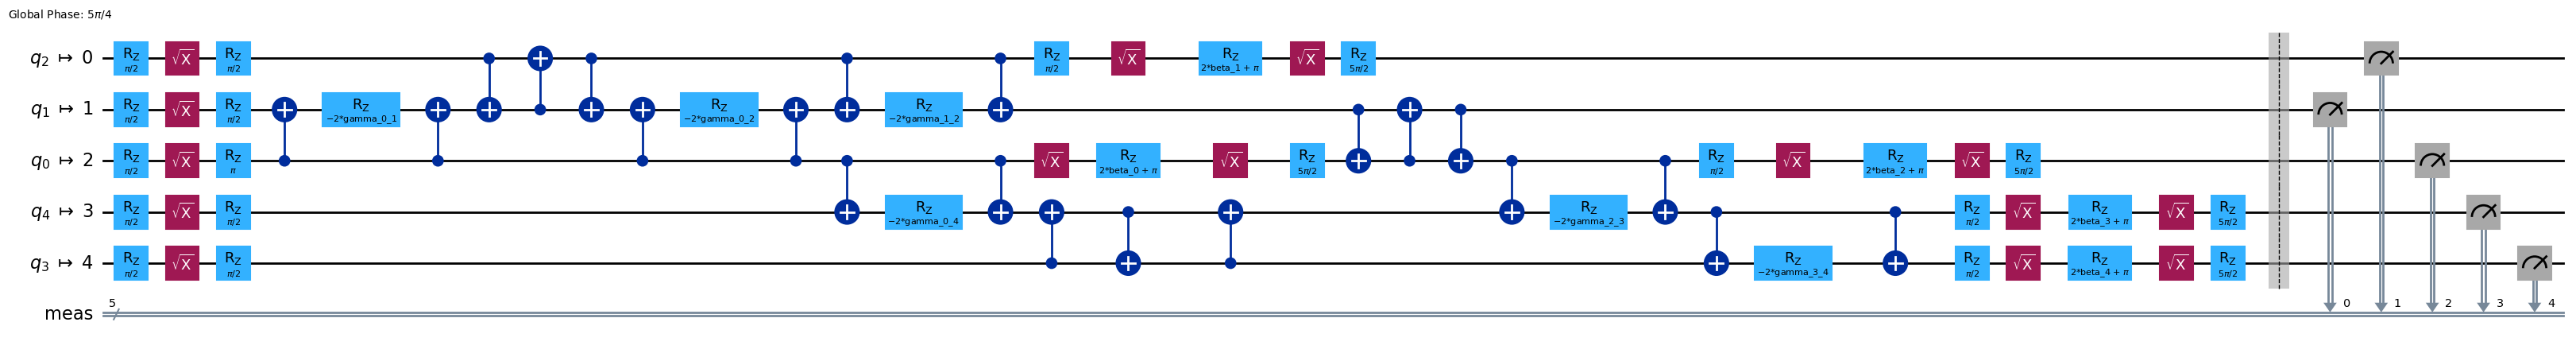

In [15]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2


# QiskitRuntimeService.save_account(channel="ibm_quantum", token="<MY_IBM_QUANTUM_TOKEN>", overwrite=True, set_as_default=True)
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend = service.least_busy(min_num_qubits=127)

backend = FakeManilaV2()

print(backend)

# Create pass manager for transpilation
pm = generate_preset_pass_manager(optimization_level=3,
                                    backend=backend)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw('mpl', fold=False, idle_wires=False)

In [16]:
pcirc = transform_to_allowed_gates(candidate_circuit)
stim_circ = qiskit_to_stim(pcirc)
stim_circ.stim_circuit().diagram()

q0: -S-S_DAG-H-S_DAG-S---------------------------------------@-X-@-------@---@-S-S_DAG-H-S_DAG-I-S_DAG-H-S_DAG-S-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                                             | | |       |   |
q1: -----------------S-S_DAG-H-S_DAG-S-----------------X-I-X-X-@-X-X-I-X-X-I-X-----------------------------------------------------------------------------------------@-X-@-------------------------------------------------------------------------------------------------------------------------------------
                                                       |   |       |   |                                                                                               | | |
q2: ---------------------------------S-S_DAG-H-S_DAG-Z-@---@-------@---@---------------------------------------------------------@---@-S_DAG-H-S_DAG-I-S_DAG-H-S_DAG-S-X-@-X-----------------------@---@-S-S_DAG-H-S_DAG-I-S_DAG-H-S_DAG-S-----------------------------------------------------------------------
                                                                                                                                 |   |                                                             |   |
q3: -----------------------------------------------------------------------------------------------------------S-S_DAG-H-S_DAG-S-X-I-X-------------------------------------------------------X-@-X-X-I-X---------------------------------@---@-S-S_DAG-H-S_DAG-I-S_DAG-H-S_DAG-S---------------------------------
                                                                                                                                                                                             | | |                                       |   |
q4: -----------------------------------------------------------------------------------------------------------------------------------------------------------------------S-S_DAG-H-S_DAG-S-@-X-@---------------------------------------X-I-X---------------------------------S-S_DAG-H-S_DAG-I-S_DAG-H-S_DAG-S-

## CAFQA to find best initial params

In [7]:
# we can perform CAFQA by using the main optimization function "claptonize"
ks_best, _, energy_best = claptonize(
    paulis,
    coeffs,
    stim_circ,
    n_proc=4,           # total number of processes in parallel
    n_starts=4,         # number of random genetic algorithm starts in parallel
    n_rounds=1,         # number of budget rounds, if None it will terminate itself
    callback=print,     # callback for internal parameter (#iteration, energies, ks) processing
    budget=20           # budget per genetic algorithm instance
)

STARTING ROUND 0


started GA at id 1 with 1 procs

started GA at id 2 with 1 procs


/home/dbharadwaj/anaconda3/envs/qaoa/lib/python3.13/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")



started GA at id None with 1 procs

started GA at id 3 with 1 procs



/home/dbharadwaj/anaconda3/envs/qaoa/lib/python3.13/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")
/home/dbharadwaj/anaconda3/envs/qaoa/lib/python3.13/site-packages/pygad/pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution

[0, array([-2., -1., -1.,  0.]), array([3, 3, 0, 2, 3, 3, 2, 3, 2, 1, 1], dtype=object)]
[0, array([-2., -1., -1.,  0.]), array([3, 3, 0, 2, 3, 3, 2, 3, 2, 1, 1], dtype=object)]
[0, array([-2., -1., -1.,  0.]), array([3, 3, 0, 2, 3, 3, 2, 3, 2, 1, 1], dtype=object)]
[0, array([-2., -1., -1.,  0.]), array([3, 3, 0, 2, 3, 3, 2, 3, 2, 1, 1], dtype=object)]
[1, array([-2., -1., -1.,  0.]), array([2, 1, 3, 3, 3, 3, 0, 3, 1, 0, 1], dtype=object)]
[1, array([-2., -1., -1.,  0.]), array([2, 1, 3, 3, 3, 3, 0, 3, 1, 0, 1], dtype=object)]
[1, array([-2., -1., -1.,  0.]), array([2, 1, 3, 3, 3, 3, 0, 3, 1, 0, 1], dtype=object)]
[1, array([-2., -1., -1.,  0.]), array([2, 1, 3, 3, 3, 3, 0, 3, 1, 0, 1], dtype=object)]
[2, array([-2., -1., -1.,  0.]), array([2, 1, 3, 3, 3, 3, 0, 3, 1, 0, 1], dtype=object)]
[2, array([-2., -1., -1.,  0.]), array([2, 1, 3, 3, 3, 3, 0, 3, 1, 0, 1], dtype=object)]
[2, array([-2., -1., -1.,  0.]), array([2, 1, 3, 3, 3, 3, 0, 3, 1, 0, 1], dtype=object)]
[3, array([-2., -1., 

In [8]:
ks_best

[2, 1, 3, 3, 3, 1, 2, 2, 3, 0, 2]

In [9]:
stim_circ.stim_circuit().diagram()

q0: -S-S_DAG-H-S_DAG-S---------------------X-Z-X-----------------------------------------------------------------------------@-------@-S-S_DAG-H-S_DAG-S_DAG-S_DAG-H-S_DAG-S---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                           |   |                                                                             |       |
q1: -----------------S-S_DAG-H-S_DAG-S_DAG-@---@-----------------@-S_DAG-H-S_DAG-S---------@-S_DAG-H-S_DAG-S-@-S_DAG-H-S_DAG-X-S_DAG-X-------------------------------------------------------------------------------------------------------------@-X-@-----------------------------------------------------------------------------------------------------------------------------------------
                                                                 |                         |                 |                                                                                                                                     | | |
q2: -------------------------------------------S-S_DAG-H-S_DAG-S-X---------------S-X-S_DAG-X---------------S-X-------------------------------------------------------------S_DAG-H-S_DAG-----------------@-------@-S_DAG-H-S_DAG-S-S_DAG-H-S_DAG-S-X-@-X-----------------------@---@-S-S_DAG-H-S_DAG-Z-S_DAG-H-S_DAG-S---------------------------------------------------------------------------
                                                                                                                                                                                                         |       |                                                             |   |
q3: -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------S-----S_DAG-H-S_DAG-S-X-S_DAG-X-------------------------------------------------------X-@-X-X-Z-X---------------------------------@-------@-S-S_DAG-H-S_DAG-I-S_DAG-H-S_DAG-S---------------------------------
                                                                                                                                                                                                                                                                         | | |                                       |       |
q4: ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------S-S_DAG-H-S_DAG-S-@-X-@---------------------------------------X-S_DAG-X---------------------------------S-S_DAG-H-S_DAG-Z-S_DAG-H-S_DAG-S-

In [10]:
stim_circ.assign(ks_best).stim_circuit().diagram()

q0: -S-S_DAG-H-S_DAG-S---------------------X-Z-X-----------------------------------------------------------------------------@-------@-S-S_DAG-H-S_DAG-S_DAG-S_DAG-H-S_DAG-S---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
                                           |   |                                                                             |       |
q1: -----------------S-S_DAG-H-S_DAG-S_DAG-@---@-----------------@-S_DAG-H-S_DAG-S---------@-S_DAG-H-S_DAG-S-@-S_DAG-H-S_DAG-X-S_DAG-X-------------------------------------------------------------------------------------------------------------@-X-@-----------------------------------------------------------------------------------------------------------------------------------------
                                                                 |                         |                 |                                                                                                                                     | | |
q2: -------------------------------------------S-S_DAG-H-S_DAG-S-X---------------S-X-S_DAG-X---------------S-X-------------------------------------------------------------S_DAG-H-S_DAG-----------------@-------@-S_DAG-H-S_DAG-S-S_DAG-H-S_DAG-S-X-@-X-----------------------@---@-S-S_DAG-H-S_DAG-Z-S_DAG-H-S_DAG-S---------------------------------------------------------------------------
                                                                                                                                                                                                         |       |                                                             |   |
q3: -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------S-----S_DAG-H-S_DAG-S-X-S_DAG-X-------------------------------------------------------X-@-X-X-Z-X---------------------------------@-------@-S-S_DAG-H-S_DAG-I-S_DAG-H-S_DAG-S---------------------------------
                                                                                                                                                                                                                                                                         | | |                                       |       |
q4: ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------S-S_DAG-H-S_DAG-S-@-X-@---------------------------------------X-S_DAG-X---------------------------------S-S_DAG-H-S_DAG-Z-S_DAG-H-S_DAG-S-

In [8]:
initial_gamma = np.pi
initial_beta = np.pi/2
init_params = [initial_gamma, initial_beta] * reps

In [9]:
objective_func_vals = []

def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    global objective_func_vals

    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)


    return cost

In [ ]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from scipy.optimize import minimize

objective_func_vals = [] # Global variable
# with Session(backend=backend) as session:
#     # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
#     estimator = Estimator(mode=session)
#     estimator.options.default_shots = 1000

#     # Set simple error suppression/mitigation options
#     estimator.options.dynamical_decoupling.enable = True
#     estimator.options.dynamical_decoupling.sequence_type = "XY4"
#     estimator.options.twirling.enable_gates = True
#     estimator.options.twirling.num_randomizations = "auto"

#     result = minimize(
#         cost_func_estimator,
#         init_params,
#         args=(candidate_circuit, cost_hamiltonian, estimator),
#         method="COBYLA",
#         tol=1e-2,
#     )
#     print(result)


estimator = Estimator(mode=backend)

result = minimize(
    cost_func_estimator,
    init_params,
    args=(candidate_circuit, cost_hamiltonian, estimator),
    method="COBYLA",
    tol=1e-3,
)
print(result)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [ ]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw('mpl', fold=False, idle_wires=False)

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# # Set simple error suppression/mitigation options
# sampler.options.dynamical_decoupling.enable = True
# sampler.options.dynamical_decoupling.sequence_type = "XY4"
# sampler.options.twirling.enable_gates = True
# sampler.options.twirling.num_randomizations = "auto"

pub= (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}
print(final_distribution_int)

In [ ]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0][0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p)].set_color("tab:purple")
plt.show()

In [ ]:
# auxiliary function to plot graphs
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(G, node_color=colors, node_size=100, alpha=0.8, pos=pos)

plot_result(graph, most_likely_bitstring)

In [ ]:
from typing import Sequence
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    assert len(x) == len(list(graph.nodes())), "The length of x must coincide with the number of nodes in the graph."
    return sum(x[u] * (1 - x[v]) + x[v] * (1 - x[u]) for u, v in list(graph.edge_list()))


cut_value= evaluate_sample(most_likely_bitstring, graph)
print('The value of the cut is:', cut_value)